# SGD Model Predictions Visualization

Visualize pixel-wise predictions from the SGD classifier across all years.
Compare predictions (with custom colormap) to ground truth labels with forest mask overlay.

In [353]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
import zarr
import pickle
import random
from pathlib import Path

# Set random seed for reproducibility
#random.seed(42)
#np.random.seed(42)

In [354]:
# Load data splits
data_split = np.load('data_split.npz', allow_pickle=True)
test_cube_indices = data_split['test_cube_indices']
test_pixel_indices = data_split['test_pixel_indices']

print(f"Test cubes available: {len(test_cube_indices)}")
print(f"Test pixels total: {len(test_pixel_indices)}")
print(f"Test cube indices sample: {test_cube_indices[:5]}")

Test cubes available: 297
Test pixels total: 1283992
Test cube indices sample: [1825 1735  678  351 1791]


In [355]:
# Load training data (contains x, y, cube_idx, disturbances, etc.)
training_data = zarr.open('training_data.zarr', mode='r')

print("Training data variables:")
print(training_data.keys())
print(f"\nTraining data dimensions: {training_data['cube_idx'].shape}")
print(f"Example cube indices: {training_data['cube_idx'][:10]}")
print(f"Example x coordinates: {training_data['x'][:10]}")
print(f"Example y coordinates: {training_data['y'][:10]}")

Training data variables:
<generator object Group.keys at 0x000001B2775F5E50>

Training data dimensions: (8155205,)
Example cube indices: [0 0 0 0 0 0 0 0 0 0]
Example x coordinates: [ 88  55 101 104  33  46  42 106   7   3]
Example y coordinates: [ 13  59  32 118  79  98  90  35  91  83]


In [356]:
# Load full dataset for forest mask and cube names
full_dataset = zarr.open('full_dataset_resizedv2.zarr', mode='r')

# Grab cube names from the full dataset (these are the original identifiers)
full_cube_names = full_dataset['cube'][:]
print(f"Full dataset variables: {list(full_dataset.keys())}")
print(f"Full dataset cube count: {len(full_cube_names)}")

def map_training_idx_to_full(training_cube_idx, cube_idx_all=None):
    """Map a training cube_idx (reindexed after filtering) to the full_dataset index via cube_name."""
    if cube_idx_all is None:
        cube_idx_all = training_data['cube_idx'][:]
    matches = np.where(cube_idx_all == training_cube_idx)[0]
    if len(matches) == 0:
        raise ValueError(f"Training cube_idx {training_cube_idx} not found in training_data")
    sample_pos = matches[0]
    cube_name_val = training_data['cube_name'][sample_pos]
    cube_name_val = cube_name_val.decode('utf-8') if isinstance(cube_name_val, bytes) else str(cube_name_val)
    full_matches = np.where(full_cube_names == cube_name_val)[0]
    if len(full_matches) == 0:
        raise ValueError(f"Cube name {cube_name_val} not found in full_dataset cube list")
    return int(full_matches[0]), cube_name_val, cube_idx_all

Full dataset variables: ['S2', 'S2_norm', 'SCL', 'SCL_count', 'SCL_count_norm', 'anyhist_disturbances', 'cloudmask', 'cube', 'dem', 'dem_norm', 'disturbance_agent', 'disturbance_prob', 'disturbances', 'forest_mask', 'forest_mask_static', 'hist_disturbances', 'lccs_class', 'norm', 'original_x', 'original_x_300', 'original_y', 'original_y_300', 'pos', 'position', 's2_band', 'scl_class', 'spatial_ref', 'statistic', 'time', 'topK', 'weather', 'weather_band', 'weather_norm', 'weather_stats', 'weather_stats_norm', 'x', 'x_300', 'y', 'y_300', 'year']
Full dataset cube count: 2216


In [357]:
# ==================================================
# OPTION 1: Select a random test cube
# ==================================================
use_random = False  # Set to False to use specific cube instead

if use_random:
    selected_cube_idx = np.random.choice(test_cube_indices)
    print(f"Selected random training cube index: {selected_cube_idx}")
else:
    # ==================================================
    # OPTION 2: Specify a particular cube index (edit below)
    # ==================================================
    selected_cube_idx = 196  # ← CHANGE THIS to your desired cube index
    
    if selected_cube_idx not in test_cube_indices:
        print(f"ERROR: Cube index {selected_cube_idx} is not in test set!")
        print(f"Available test cube indices: {sorted(test_cube_indices)[:20]}...")
        raise ValueError(f"Cube {selected_cube_idx} not in test set")
    
    print(f"Selected specific training cube index: {selected_cube_idx}")

# Map training cube_idx to full_dataset index via cube_name
selected_full_cube_idx, selected_cube_name, cube_idx_all = map_training_idx_to_full(selected_cube_idx)
print(f"Resolved cube name: {selected_cube_name}")
print(f"Full dataset cube index: {selected_full_cube_idx}")

# Find all pixels from this cube in the training data (across all years)
cube_pixels_mask = cube_idx_all == selected_cube_idx
cube_pixels_indices = np.where(cube_pixels_mask)[0]

print(f"Total pixels from cube {selected_cube_name} (train idx {selected_cube_idx}): {len(cube_pixels_indices)}")

Selected specific training cube index: 196
Resolved cube name: mc_0.75_42.84_1.1_20230611_0
Full dataset cube index: 246
Total pixels from cube mc_0.75_42.84_1.1_20230611_0 (train idx 196): 2478


In [358]:
# Extract spatial information for this cube
x_coords = training_data['x'][cube_pixels_indices]
y_coords = training_data['y'][cube_pixels_indices]

# Check year structure
print(f"Year shape: {training_data['year'].shape}")
print(f"Year sample values: {training_data['year'][:]}")

print(f"X coordinates range: {x_coords.min()} to {x_coords.max()}")
print(f"Y coordinates range: {y_coords.min()} to {y_coords.max()}")

# Get unique coordinates to determine grid size
unique_x = np.unique(x_coords)
unique_y = np.unique(y_coords)
print(f"Unique X values: {len(unique_x)}, Unique Y values: {len(unique_y)}")

Year shape: (7,)
Year sample values: [2016 2017 2018 2019 2020 2021 2022]
X coordinates range: 0 to 127
Y coordinates range: 0 to 127
Unique X values: 128, Unique Y values: 128


In [359]:
# Load forest masks for all years for the selected cube (using full dataset index)
forest_masks_by_year = full_dataset['forest_mask'][selected_full_cube_idx, :, :, :]
print(f"Forest masks shape (all years): {forest_masks_by_year.shape}")
print(f"Forest mask unique values: {np.unique(forest_masks_by_year)}")

# Check if forest mask is static across years
is_static = np.all(forest_masks_by_year == forest_masks_by_year[0])
print(f"Forest mask is static across years: {is_static}")

# Also load the forest_mask_static if available
try:
    forest_mask_static = full_dataset['forest_mask_static'][selected_full_cube_idx, :, :]
    print(f"Forest mask static shape: {forest_mask_static.shape}")
except:
    forest_mask_static = None
    print("Forest mask static not available")

Forest masks shape (all years): (7, 128, 128)
Forest mask unique values: [0 1]
Forest mask is static across years: False
Forest mask static shape: (128, 128)


In [360]:
def create_custom_colormap():
    """
    Create custom colormap for prediction probabilities:
    Continuous spectrum from green (prob=0) to red (prob=1)
    """
    from matplotlib.colors import LinearSegmentedColormap
    
    # Create continuous colormap from green to red
    colors = ['green', 'red']
    n_bins = 256
    cmap = LinearSegmentedColormap.from_list('green_red', colors, N=n_bins)
    norm = None  # Use default normalization (0 to 1)
    
    return cmap, norm

# Test the colormap
cmap, norm = create_custom_colormap()
print("Custom colormap created successfully")

Custom colormap created successfully


In [361]:
def create_spatial_grids(x_coords, y_coords, values, grid_shape=None):
    """
    Create spatial grids from scattered pixel coordinates and values.
    Only pixels in the training set will have values; others will be NaN.
    """
    if grid_shape is None:
        max_x = int(x_coords.max()) + 1
        max_y = int(y_coords.max()) + 1
        grid_shape = (max_y, max_x)
    
    grid = np.full(grid_shape, np.nan)
    
    for i, (x, y, val) in enumerate(zip(x_coords, y_coords, values)):
        x_idx = int(x)
        y_idx = int(y)
        if 0 <= y_idx < grid_shape[0] and 0 <= x_idx < grid_shape[1]:
            grid[y_idx, x_idx] = val
    
    return grid

# Determine full grid shape
max_x = int(x_coords.max()) + 1
max_y = int(y_coords.max()) + 1
grid_shape = (max_y, max_x)
print(f"Grid shape will be: {grid_shape}")

Grid shape will be: (128, 128)


In [362]:
def load_year_model(year):
    """Load the model trained for a specific year."""
    model_path = Path(f'models_neighbours/model_year_{year}.pkl')
    if not model_path.exists():
        print(f"Warning: Model for year {year} not found at {model_path}")
        return None
    
    with open(model_path, 'rb') as f:
        model = pickle.load(f)
    return model

def load_year_scaler(year):
    """Load the StandardScaler fitted for a specific year (if available)."""
    scaler_path = Path(f'models_neighbours/scaler_year_{int(year)}.pkl')
    if not scaler_path.exists():
        print(f"Warning: Scaler for year {year} not found at {scaler_path}")
        return None
    try:
        with open(scaler_path, 'rb') as f:
            scaler = pickle.load(f)
        return scaler
    except Exception as e:
        print(f"Warning: Failed to load scaler for year {year}: {e}")
        return None

# Check which year models are available
models_dir = Path('models_neighbours')
available_years = []
for year in [2017, 2018, 2019, 2020, 2021, 2022]:
    model_path = models_dir / f'model_year_{year}.pkl'
    if model_path.exists():
        available_years.append(year)

print(f"Available year models: {available_years}")

Available year models: [2017, 2018, 2019, 2020, 2021, 2022]


In [363]:
# Load training data with neighbourhood features
training_data_features = zarr.open('training_data_with_neighbourhood_features.zarr', mode='r')

print("Training data with neighbourhood features variables:")
print(list(training_data_features.keys()))
print(f"Dimensions: {training_data_features['dem'].shape}")

Training data with neighbourhood features variables:
['cube_idx', 'cube_name', 'dem', 'disturbances', 'nbr', 'nbr_delta', 'ndvi', 'ndvi_delta', 'ndvi_neighbour', 'ndwi', 'ndwi_delta', 'ndwi_neighbour', 'pixel', 's2_b03_neighbour', 's2_b04_neighbour', 's2_band', 's2_bands', 'x', 'y', 'year', 'year_disturbance']
Dimensions: (8155205, 7)


In [364]:
def extract_features_for_cube_year(cube_pixels_indices, year_idx, training_data_features):
    """
    Extract feature vectors for a cube at a specific year, including neighbourhood features.
    Returns features array suitable for model prediction.
    NaN values are filled with 0 for prediction.
    """
    # Get S2 bands (8 bands)
    s2_bands = training_data_features['s2_bands'][cube_pixels_indices, year_idx, :].astype(np.float64)
    
    # Get DEM (same for all years, take from year_idx anyway)
    dem = training_data_features['dem'][cube_pixels_indices, year_idx:year_idx+1].astype(np.float64)
    
    # Get spectral indices
    ndvi = training_data_features['ndvi'][cube_pixels_indices, year_idx:year_idx+1].astype(np.float64)
    ndwi = training_data_features['ndwi'][cube_pixels_indices, year_idx:year_idx+1].astype(np.float64)
    nbr = training_data_features['nbr'][cube_pixels_indices, year_idx:year_idx+1].astype(np.float64)
    
    # Get neighbourhood features
    ndvi_neighbour = training_data_features['ndvi_neighbour'][cube_pixels_indices, year_idx:year_idx+1].astype(np.float64)
    ndwi_neighbour = training_data_features['ndwi_neighbour'][cube_pixels_indices, year_idx:year_idx+1].astype(np.float64)
    s2_b03_neighbour = training_data_features['s2_b03_neighbour'][cube_pixels_indices, year_idx:year_idx+1].astype(np.float64)
    s2_b04_neighbour = training_data_features['s2_b04_neighbour'][cube_pixels_indices, year_idx:year_idx+1].astype(np.float64)
    
    # Get deltas (only available for year_idx >= 1)
    if year_idx >= 1:
        ndvi_delta = training_data_features['ndvi_delta'][cube_pixels_indices, year_idx:year_idx+1].astype(np.float64)
        ndwi_delta = training_data_features['ndwi_delta'][cube_pixels_indices, year_idx:year_idx+1].astype(np.float64)
        nbr_delta = training_data_features['nbr_delta'][cube_pixels_indices, year_idx:year_idx+1].astype(np.float64)
    else:
        # For year 0, deltas are 0
        ndvi_delta = np.zeros((len(cube_pixels_indices), 1))
        ndwi_delta = np.zeros((len(cube_pixels_indices), 1))
        nbr_delta = np.zeros((len(cube_pixels_indices), 1))
    
    # Concatenate all features in the correct order:
    # s2_bands(8), dem(1), ndvi(1), ndwi(1), nbr(1), 
    # ndvi_neighbour(1), ndwi_neighbour(1), s2_b03_neighbour(1), s2_b04_neighbour(1),
    # ndvi_delta(1), ndwi_delta(1), nbr_delta(1)
    features = np.hstack([
        s2_bands, dem, ndvi, ndwi, nbr,
        ndvi_neighbour, ndwi_neighbour, s2_b03_neighbour, s2_b04_neighbour,
        ndvi_delta, ndwi_delta, nbr_delta
    ])
    
    # For prediction, impute NaN values with 0
    features_for_pred = features.copy()
    features_for_pred[np.isnan(features_for_pred)] = 0.0
    
    # Return both: features_for_pred (for model) and original features (to track NaNs)
    return features_for_pred, features

print("Feature extraction function with neighbourhood features and NaN tracking defined")

Feature extraction function with neighbourhood features and NaN tracking defined


In [365]:
# Create a mapping from year values to year indices
year_values = training_data['year'][:]
year_to_idx = {year: idx for idx, year in enumerate(year_values)}

print(f"Year mapping: {year_to_idx}")

# Get ground truth disturbances for all pixels in this cube (all years)
disturbances_all = training_data_features['disturbances'][cube_pixels_indices, :]
print(f"Disturbances shape for cube: {disturbances_all.shape}")

Year mapping: {2016: 0, 2017: 1, 2018: 2, 2019: 3, 2020: 4, 2021: 5, 2022: 6}
Disturbances shape for cube: (2478, 7)


In [366]:
def create_forest_mask_overlay(forest_mask_2d, alpha=0.3):
    """
    Create an RGBA overlay for forest mask.
    Light purple (for forest=1) with alpha transparency.
    """
    overlay = np.zeros((*forest_mask_2d.shape, 4), dtype=np.float32)
    # For forest pixels (value=1), set to light purple with transparency
    forest_pixels = forest_mask_2d == 1
    overlay[forest_pixels, :] = [0.8, 0.5, 0.8, alpha]  # Light purple (RGBA)
    return overlay

print("Forest mask overlay function created")

Forest mask overlay function created


In [367]:
def create_spatial_grid_with_nan(x_coords, y_coords, values, grid_shape=None):
    """
    Create spatial grid preserving NaN values.
    Pixels not in the training set or with NaN values remain NaN.
    """
    if grid_shape is None:
        max_x = int(x_coords.max()) + 1
        max_y = int(y_coords.max()) + 1
        grid_shape = (max_y, max_x)
    
    grid = np.full(grid_shape, np.nan)
    
    for i, (x, y, val) in enumerate(zip(x_coords, y_coords, values)):
        x_idx = int(x)
        y_idx = int(y)
        if 0 <= y_idx < grid_shape[0] and 0 <= x_idx < grid_shape[1]:
            grid[y_idx, x_idx] = val
    
    return grid

def visualize_year(year, year_idx, model, year_scaler, cube_pixels_indices, x_coords, y_coords, 
                   disturbances_all, forest_mask_year, grid_shape, cmap, norm):
    """
    Create visualization for a specific year.
    Shows predictions vs ground truth side by side.
    NaNs are displayed as black.
    Uses the forest mask for the specific year.
    """
    # Extract features for this year
    features_for_pred, features_with_nan = extract_features_for_cube_year(cube_pixels_indices, year_idx, training_data_features)
    
    # Scale features before making predictions (if year-specific scaler exists)
    if year_scaler is not None:
        try:
            features_scaled = year_scaler.transform(features_for_pred)
        except Exception as e:
            print(f"  Warning: Could not scale features for year {year}: {e}")
            features_scaled = features_for_pred
    else:
        print(f"  Warning: No scaler available for year {year}, using unscaled features")
        features_scaled = features_for_pred
    
    # Make predictions
    probabilities = model.predict_proba(features_scaled)[:, 1]  # Probability of class 1 (disturbance)
    ground_truth = disturbances_all[:, year_idx]
    
    # Mark pixels with NaN in any feature as NaN in output (for visualization)
    has_nan = np.any(np.isnan(features_with_nan), axis=1)
    probabilities_vis = probabilities.copy().astype(np.float64)
    probabilities_vis[has_nan] = np.nan
    
    # Create spatial grids
    pred_grid = create_spatial_grid_with_nan(x_coords, y_coords, probabilities_vis, grid_shape)
    gt_grid = create_spatial_grid_with_nan(x_coords, y_coords, ground_truth, grid_shape)
    
    # Create figure with two subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    
    # Plot 1: Predictions with NaN as black and forest mask overlay
    im1 = ax1.imshow(pred_grid, cmap=cmap, norm=norm, origin='upper')
    # Add black background for NaN values
    nan_mask = np.isnan(pred_grid)
    ax1.imshow(np.where(nan_mask[:, :, None], 0, 1), cmap='gray', origin='upper', vmin=0, vmax=1, alpha=0.3)
    forest_overlay = create_forest_mask_overlay(forest_mask_year, alpha=0.2)
    ax1.imshow(forest_overlay, origin='upper')
    ax1.set_title(f'Predictions - {year}', fontsize=12, fontweight='bold')
    ax1.set_xlabel('X coordinate')
    ax1.set_ylabel('Y coordinate')
    plt.colorbar(im1, ax=ax1, label='Disturbance Probability')
    
    # Plot 2: Ground truth with NaN as black and forest mask overlay
    gt_cmap = ListedColormap(['green', 'red'])
    gt_norm = BoundaryNorm([0, 0.5, 1.0], 2)
    im2 = ax2.imshow(gt_grid, cmap=gt_cmap, norm=gt_norm, origin='upper')
    # Add black background for NaN values
    nan_mask_gt = np.isnan(gt_grid)
    ax2.imshow(np.where(nan_mask_gt[:, :, None], 0, 1), cmap='gray', origin='upper', vmin=0, vmax=1, alpha=0.3)
    ax2.imshow(forest_overlay, origin='upper')
    ax2.set_title(f'Ground Truth - {year}', fontsize=12, fontweight='bold')
    ax2.set_xlabel('X coordinate')
    ax2.set_ylabel('Y coordinate')
    cbar2 = plt.colorbar(im2, ax=ax2, label='Disturbance Label', ticks=[0.25, 0.75])
    cbar2.set_ticklabels(['No Disturbance', 'Disturbance'])
    
    plt.tight_layout()
    return fig, probabilities, ground_truth

print("Updated visualization function to use year-specific forest mask and scaler")

Updated visualization function to use year-specific forest mask and scaler


Creating visualizations for cube: mc_0.75_42.84_1.1_20230611_0 (train idx 196, full idx 246)
Cube contains 2478 pixels from training set
Output directory: c:\Users\bartu\Desktop\Fonda-scikit\prediction visualizations with neighbourhoods


Processing year 2017 (index 1) for cube mc_0.75_42.84_1.1_20230611_0...
  ✓ Saved to: prediction visualizations with neighbourhoods\mc_0.75_42.84_1.1_20230611_0_2017.png
  ✓ Mean prediction probability: 0.324
  ✓ Ground truth disturbance ratio: 0.625

Processing year 2018 (index 2) for cube mc_0.75_42.84_1.1_20230611_0...
  ✓ Saved to: prediction visualizations with neighbourhoods\mc_0.75_42.84_1.1_20230611_0_2018.png
  ✓ Mean prediction probability: 0.004
  ✓ Ground truth disturbance ratio: 0.617

Processing year 2019 (index 3) for cube mc_0.75_42.84_1.1_20230611_0...
  ✓ Saved to: prediction visualizations with neighbourhoods\mc_0.75_42.84_1.1_20230611_0_2019.png
  ✓ Mean prediction probability: 0.301
  ✓ Ground truth disturbance ratio: 0.642

Proce

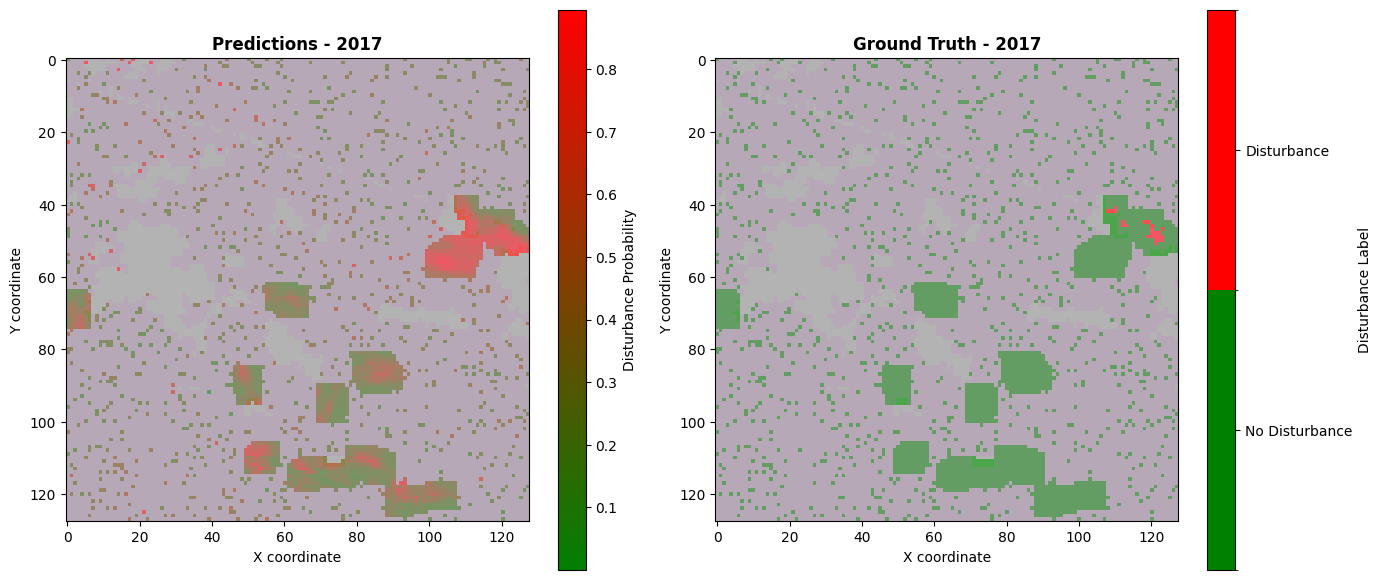

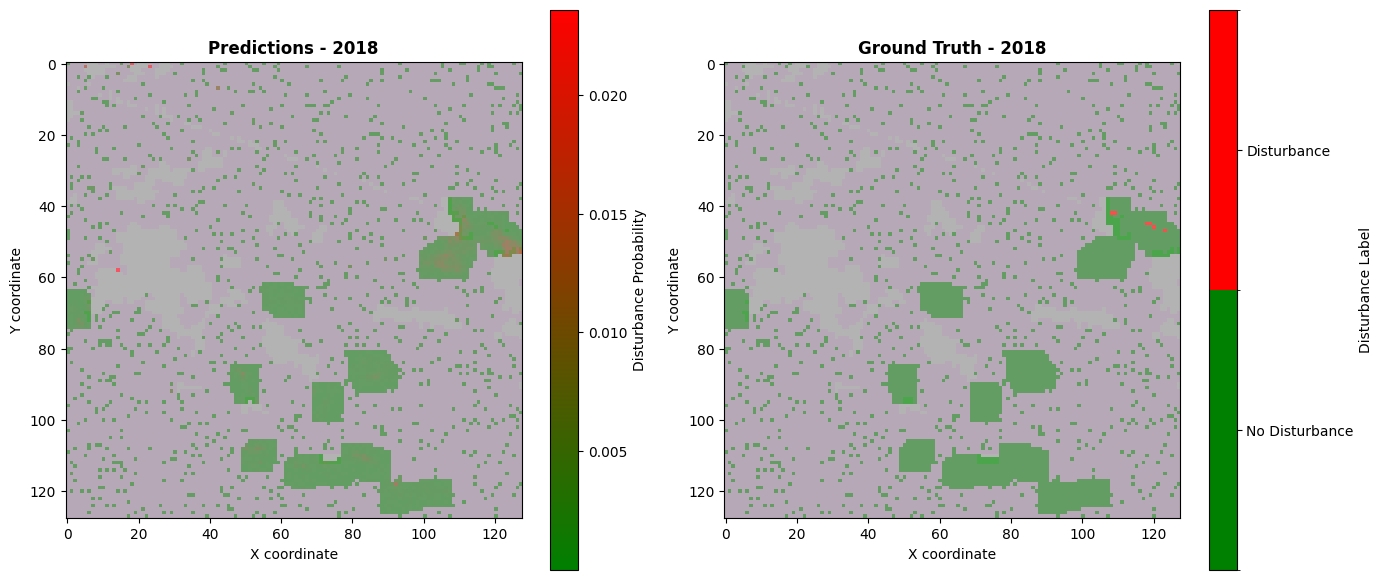

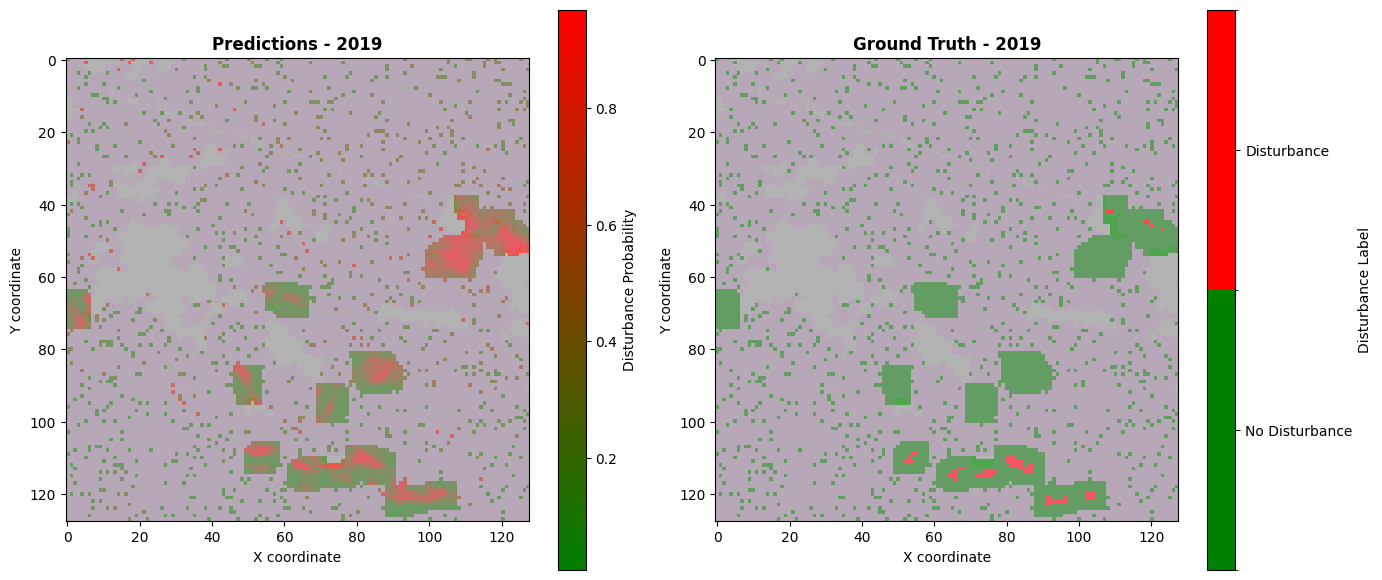

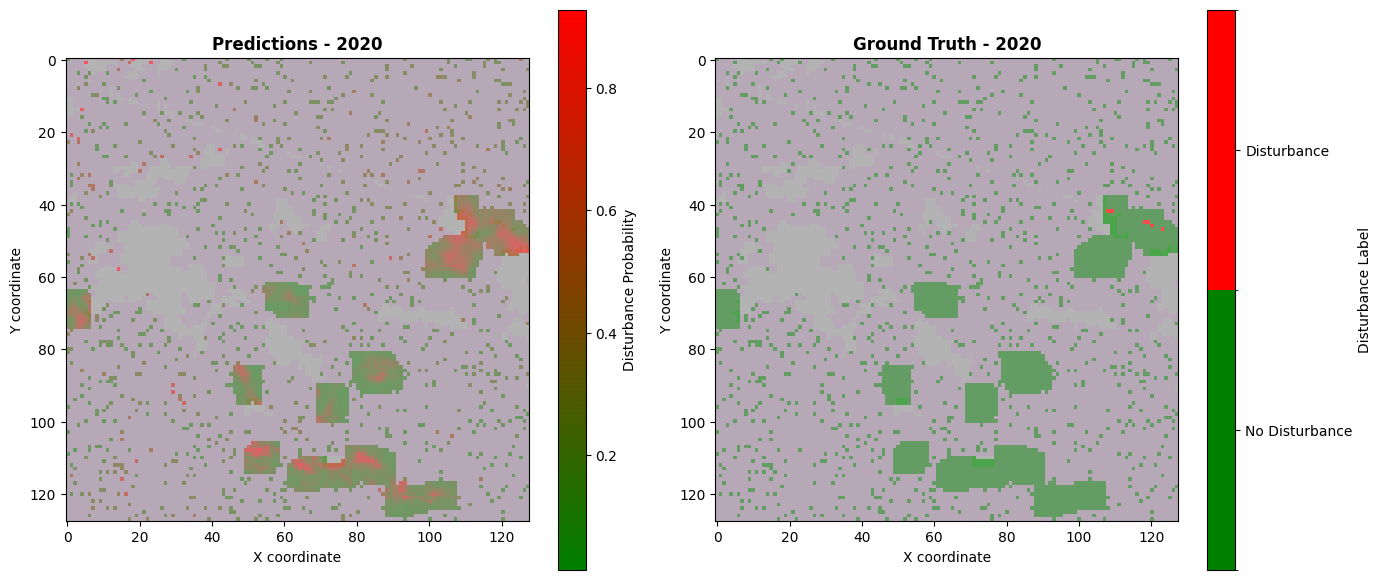

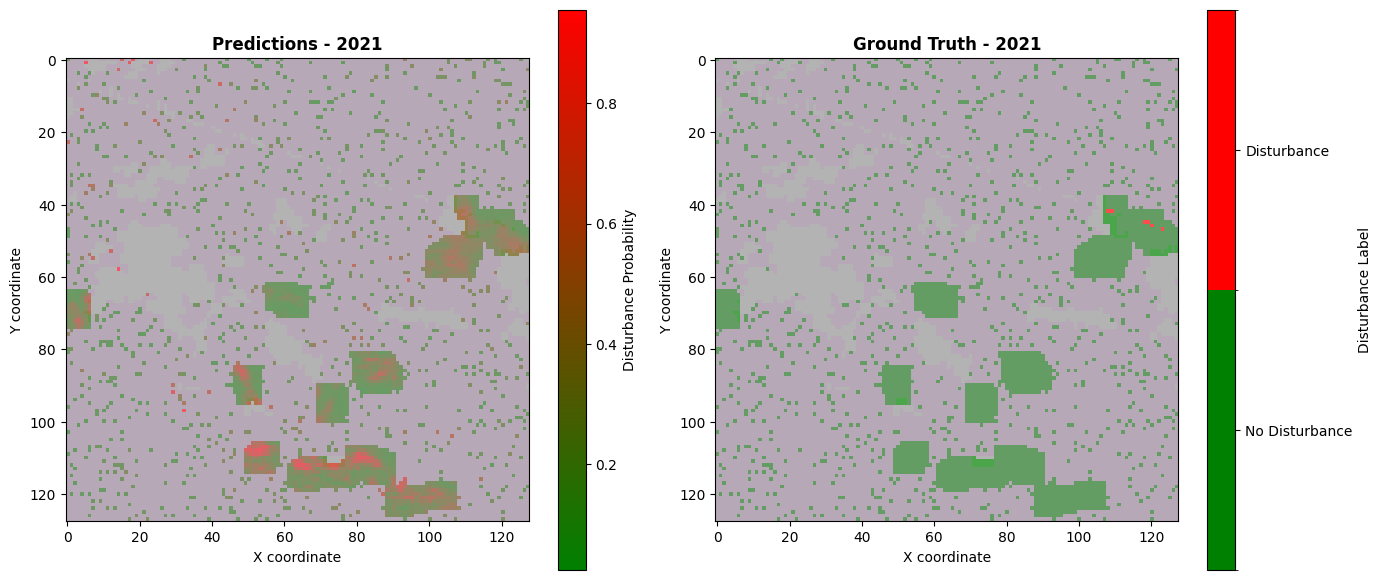

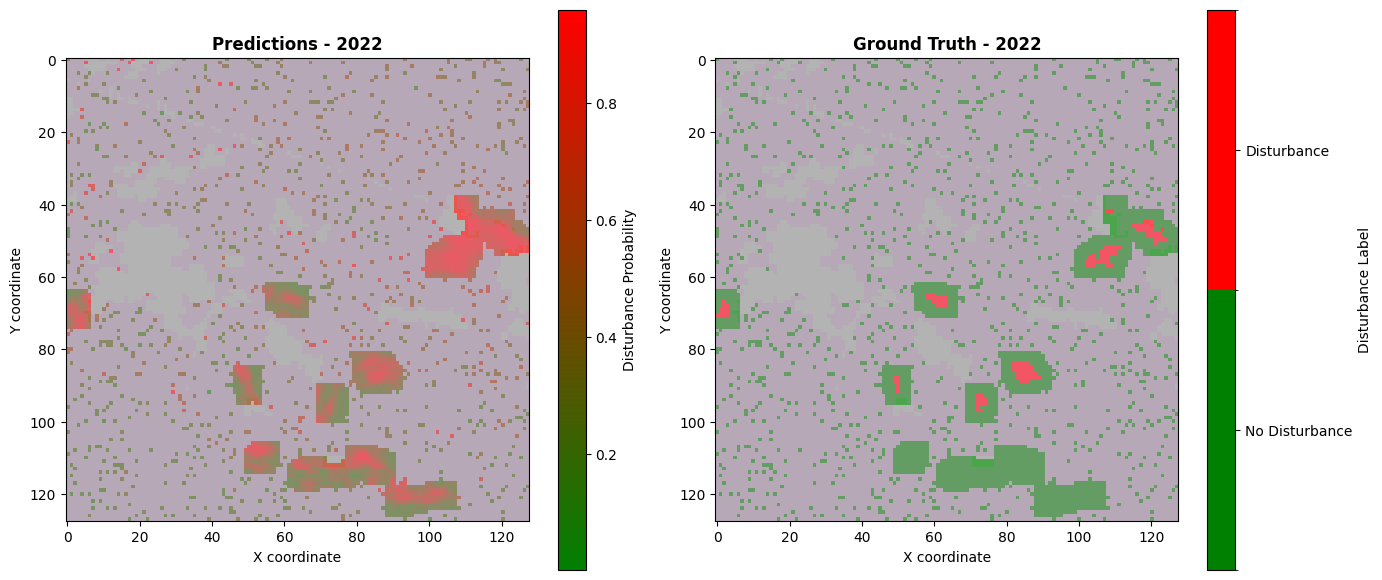

In [368]:
# Create visualizations for all available years
print(f"Creating visualizations for cube: {selected_cube_name} (train idx {selected_cube_idx}, full idx {selected_full_cube_idx})")
print(f"Cube contains {len(cube_pixels_indices)} pixels from training set")
print(f"=" * 60)

# Create output directory for visualizations
output_dir = Path('prediction visualizations with neighbourhoods')
output_dir.mkdir(exist_ok=True)
print(f"Output directory: {output_dir.absolute()}\n")

# Create colormap
cmap, norm = create_custom_colormap()

# Store results
all_figures = []
results_by_year = {}

# Years to visualize (2017-2022, indices 1-6)
years_to_visualize = [2017, 2018, 2019, 2020, 2021, 2022]

for year in years_to_visualize:
    year_idx = year_to_idx[year]
    
    # Load the model for this year
    model = load_year_model(year)
    if model is None:
        print(f"Skipping year {year} - model not found")
        continue
    
    # Load the scaler for this year
    year_scaler = load_year_scaler(year)
    
    print(f"\nProcessing year {year} (index {year_idx}) for cube {selected_cube_name}...")
    
    try:
        # Get forest mask for this specific year
        forest_mask_year = forest_masks_by_year[year_idx, :, :]
        
        # Create visualization
        fig, probabilities, ground_truth = visualize_year(
            year, year_idx, model, year_scaler, cube_pixels_indices, x_coords, y_coords,
            disturbances_all, forest_mask_year, grid_shape, cmap, norm
)
        
        # Save the figure with cube name in filename
        filename = output_dir / f"{selected_cube_name}_{year}.png"
        fig.savefig(filename, dpi=150, bbox_inches='tight')
        print(f"  ✓ Saved to: {filename}")
        
        all_figures.append((year, fig))
        results_by_year[year] = {
            'probabilities': probabilities,
            'ground_truth': ground_truth,
            'mean_probability': probabilities.mean(),
            'disturbance_ratio': ground_truth.mean()
        }
        
        print(f"  ✓ Mean prediction probability: {probabilities.mean():.3f}")
        print(f"  ✓ Ground truth disturbance ratio: {ground_truth.mean():.3f}")
        
    except Exception as e:
        print(f"  ✗ Error processing year {year} for cube {selected_cube_name}: {str(e)}")
        import traceback
        traceback.print_exc()
        continue

print(f"\n{'=' * 60}")
print(f"Completed visualizations for {len(all_figures)} years on cube {selected_cube_name}")
print(f"All images saved to: {output_dir.absolute()}")